In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
import warnings
import optuna
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree  import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import BernoulliNB
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFE , SelectKBest, f_regression
import itertools
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from tabulate import tabulate
from sklearn.metrics import classification_report
from sklearn import metrics
import os
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Data Preprocessing 

In [28]:
# read the data 

data_train = pd.read_csv("Train_data.csv")

data_test = pd.read_csv("Test_data.csv")

In [29]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  str    
 2   service                      25192 non-null  str    
 3   flag                         25192 non-null  str    
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell                 

In [30]:
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [31]:
data_train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
data_train.describe(include='object')

,protocol_type,service,flag,class
count,25192,25192,25192,25192
unique,3,66,11,2
top,tcp,http,SF,normal
freq,20526,8003,14973,13449


In [33]:
data_train['class'].value_counts()

class
normal     13449
anomaly    11743
Name: count, dtype: int64

In [34]:
data_train.shape

(25192, 42)

# Data Encoding

In [35]:
# Identify object columns 
object_columns_train = data_train.select_dtypes(include=['object']).columns

object_coulumns_test = data_test.select_dtypes(include=['object']).columns

# Initialize LabelEncoder 
label_encoder = LabelEncoder()
# apply label encoding to each object columns 
for col in object_columns_train:
    data_train[col] = label_encoder.fit_transform(data_train[col])

for col in object_coulumns_test:
    data_test[col] = label_encoder.fit_transform(data_test[col])


In [36]:
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,1,19,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1
1,0,2,41,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1
2,0,1,46,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,0,1,22,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1
4,0,1,22,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1


# Explore Data Analysis (EDA)

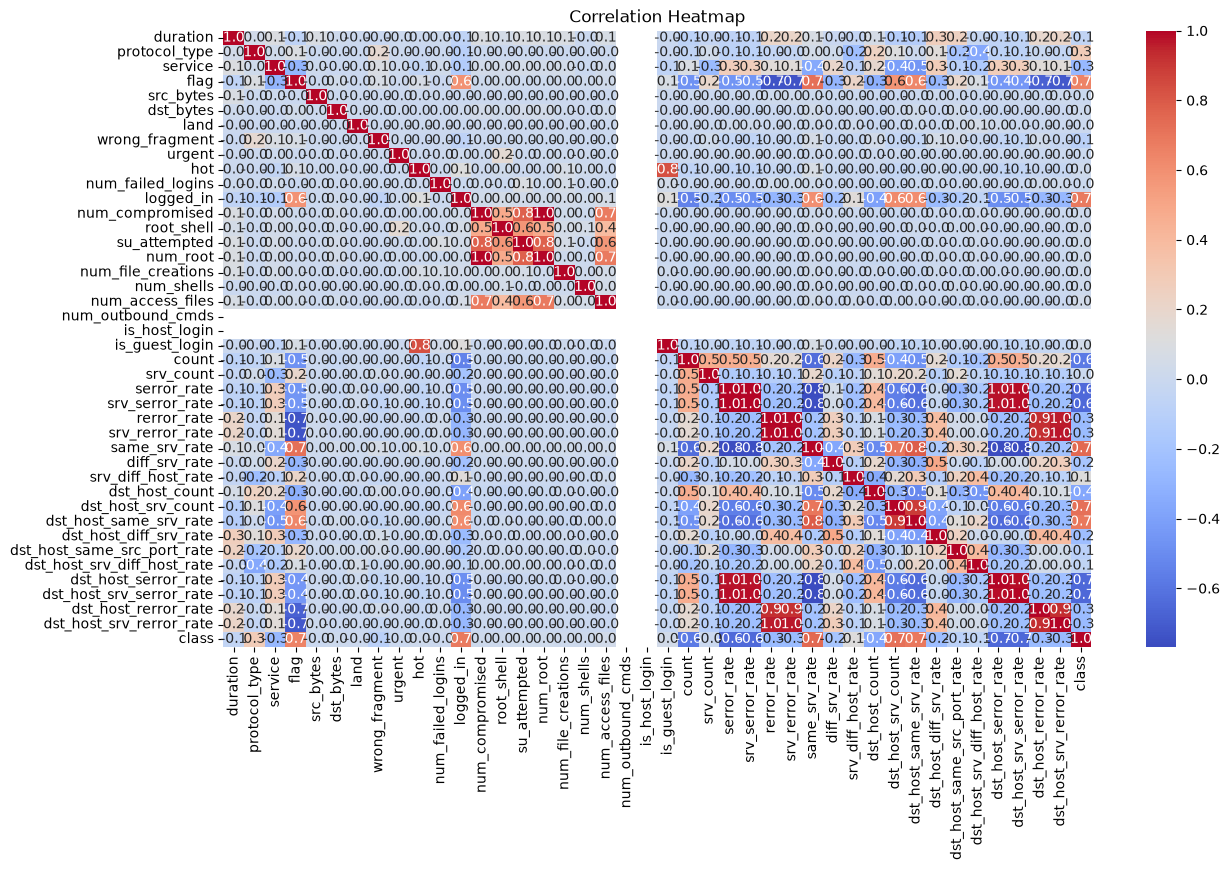

In [37]:
correlation_matrix = data_train.corr()

# create a heatmap 
plt.figure(figsize=(14,8))
sns.heatmap(correlation_matrix , annot=True , cmap='coolwarm' , fmt='.1f')
plt.title('Correlation Heatmap')
plt.show()

As we can see, (0.0) means there is no correlation 

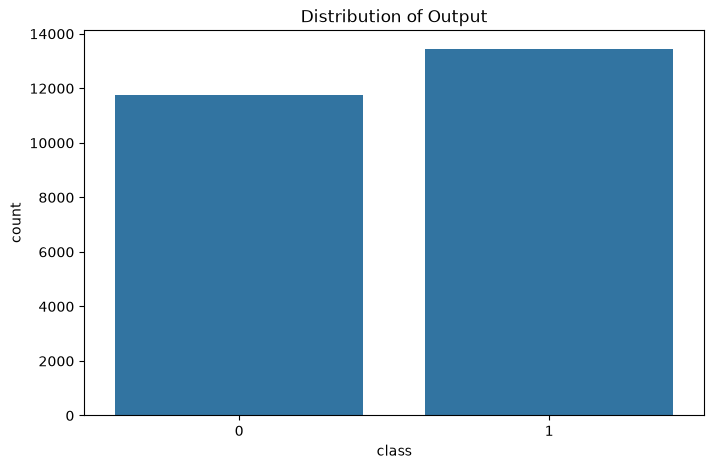

In [38]:
# Visualize the distribution of the target variable 
plt.figure(figsize=(8,5))
sns.countplot(x='class' , data = data_train)
plt.title("Distribution of Output")
plt.show()

In [39]:
# Extract input and output 
x = data_train.iloc[:,:-1]
y = data_train.iloc[:,-1]

x_test = data_test

# Data Scaling 

In [40]:
# Initialize the StandardScaler 
scaler = StandardScaler() # ( range -3 to 3 )

# Fit the scaler to your training data and transform both train and test features 
x_scaled = scaler.fit_transform(x)
x_scaled_test = scaler.transform(x_test)


In [41]:
print(x_scaled[:1])

[[-0.11355066 -0.12606067 -0.64538418  0.75302096 -0.00988885 -0.03930979
  -0.00891048 -0.09122318 -0.00630053 -0.09193335 -0.02622029 -0.80762582
  -0.02187261 -0.03937653 -0.02766547 -0.02172416 -0.02780802 -0.0189046
  -0.04391678  0.          0.         -0.09598961 -0.7202436  -0.35462794
  -0.64014201 -0.63397817 -0.3721856  -0.37309835  0.77210866 -0.34928194
  -0.37388608 -0.32863359 -0.81398452 -0.7791569  -0.2806733   0.07311974
  -0.28799346 -0.64180407 -0.62736475 -0.22166806 -0.37428075]]


In [42]:
print(x_scaled_test[:1])

[[-0.11355066 -0.12606067  1.02607271 -2.23286879 -0.01009252 -0.03930979
  -0.00891048 -0.09122318 -0.00630053 -0.09193335 -0.02622029 -0.80762582
  -0.02187261 -0.03937653 -0.02766547 -0.02172416 -0.02780802 -0.0189046
  -0.04391678  0.          0.         -0.09598961  1.25932973 -0.24423257
  -0.64014201 -0.63397817  2.76517615  2.72932229 -1.41155246 -0.01323494
  -0.37388608  0.73205893 -0.94955366 -1.06873111 -0.1204061  -0.47818309
  -0.28799346 -0.64180407 -0.62736475  2.88429591  2.77704096]]


# Features Selection

In [43]:
# Initialize SelectKBest with the scoring function 
selector = SelectKBest(score_func=f_regression , k=25)

# fit and transform your data 
x = selector.fit_transform(x_scaled,y)
x_test = selector.transform(x_scaled_test)

# Split The Data

In [44]:
# split the data into 80 for training and 20 for testing 
x_train , x_val , y_train , y_val = train_test_split(x,y, test_size=0.2 , random_state=42)

In [45]:
print(x_train.shape)
print(x_val.shape)

(20153, 25)
(5039, 25)


# Modeling

**RandomForestClassifier**

In [46]:
# Initialize the RandomForestClassifier 
rf_classifier = RandomForestClassifier(n_estimators=100 , random_state=42)

# fit the classifier to the training data 
rf_classifier.fit(x_train , y_train)

# make predictions on the testing data 
y_pred = rf_classifier.predict(x_val)

Classification Report:
              precision    recall  f1-score   support

           0     0.9962    0.9928    0.9945      2365
           1     0.9937    0.9966    0.9951      2674

    accuracy                         0.9948      5039
   macro avg     0.9949    0.9947    0.9948      5039
weighted avg     0.9948    0.9948    0.9948      5039



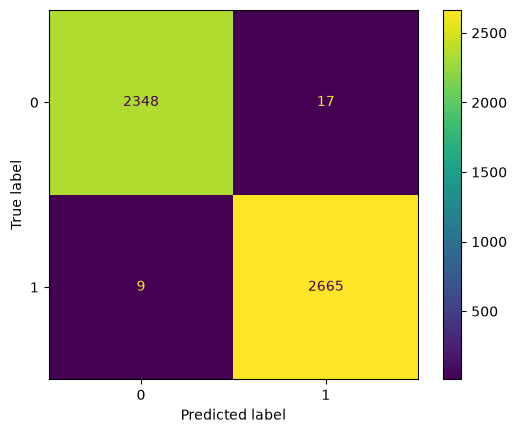

In [47]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn import metrics

# Classification report
class_report = classification_report(y_val, y_pred, digits=4)
print("Classification Report:")
print(class_report)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
cm_display.plot()
plt.show()


**Logistic Regression**

In [48]:
# Initialize LogisticRegression 
logreg_model = LogisticRegression(random_state=42)

# fit the model to the training data 
logreg_model.fit(x_train , y_train)

# make predictions on the testing data 
y_pred = logreg_model.predict(x_val)

Classification Report:
              precision    recall  f1-score   support

           0     0.9609    0.9455    0.9531      2365
           1     0.9524    0.9660    0.9592      2674

    accuracy                         0.9563      5039
   macro avg     0.9567    0.9557    0.9561      5039
weighted avg     0.9564    0.9563    0.9563      5039



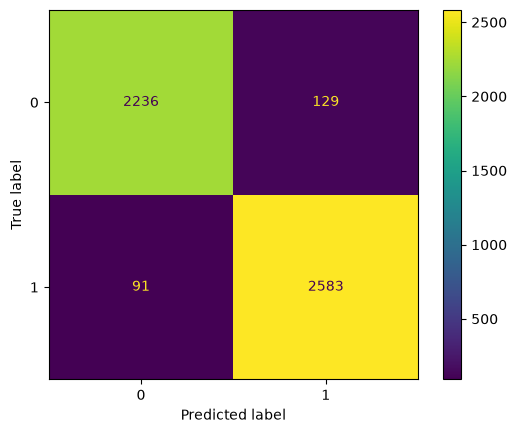

In [49]:
# Classification report
class_report = classification_report(y_val, y_pred, digits=4)
print("Classification Report:")
print(class_report)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
cm_display.plot()
plt.show()

In [50]:
# predict the x_test using the best model 

y_pred_test = rf_classifier.predict(x_test)
print(y_pred_test[:10])

[0 0 1 0 1 1 1 1 1 1]


In [51]:
# Save the Output of y_pred_test in new columns as output in the "Test_data_output.csv " file 

data_test['output'] = y_pred_test 
data_test.to_csv('Test_data_output.csv' , index=False)

In [52]:
import joblib

# Export the trained RandomForestClassifier model
model_filename = 'network_intrusion_detection_model.pkl'
joblib.dump(rf_classifier, model_filename)

print(f"Model successfully exported and saved as '{model_filename}'")


Model successfully exported and saved as 'network_intrusion_detection_model.pkl'


**Thank you for reading this notebook!**
If you found the analysis useful or informative, please consider giving it an Upvote.
Your support motivates me to continue sharing more insights and improving the content.